# Bias-Corrected CMIP6 Warming Projections — Empirical Quantile Mapping

This notebook extends the earlier CMIP6/SSP warming analysis with an
**observational bias-correction step**. Raw GCM output (here, MRI-ESM2-0)
carries systematic biases relative to local observations because of coarse
grid resolution and parameterized physics — a model can get the *warming
trend* right while still being several degrees off in absolute temperature
for a given region.

To correct for this, we use **Empirical Quantile Mapping (EQM)** via the
`xsdba` library: we learn a correction function that maps the model's
historical value distribution onto the *observed* value distribution
(IMD gridded temperature data), one calendar month at a time, then apply
that same correction to the future SSP2-4.5 projection before computing
warming anomalies.

**Pipeline:**
1. Load CMIP6 historical + SSP2-4.5 model output (MRI-ESM2-0)
2. Crop both to the Indian subcontinent domain
3. Load and clean observed gridded temperature data (IMD)
4. Bias-correct the historical model run against IMD observations (train EQM)
5. Apply the trained correction to the future SSP2-4.5 projection
6. Compute warming anomalies relative to the observed baseline
7. Aggregate into near-term (2021–2050) and long-term (2071–2100) windows
8. Visualize spatial warming patterns over Indian districts


## 1. Load CMIP6 model output

Historical (1850–2014) and SSP2-4.5 projection (2015–2100) runs for a single model, MRI-ESM2-0, realization r1i1p1f1.

In [2]:
import xarray as xr

In [3]:
ds_hist = xr.open_dataset("../data/tas_Amon_MRI-ESM2-0_historical_r1i1p1f1_gn_185001-201412.nc")
ds_ssp = xr.open_dataset("../data/tas_Amon_MRI-ESM2-0_ssp245_r1i1p1f1_gn_201501-210012.nc")

Quick inspection of the historical dataset's structure, grid resolution, and metadata before doing anything else with it.

In [4]:
print(ds_hist)

<xarray.Dataset> Size: 406MB
Dimensions:    (time: 1980, bnds: 2, lat: 160, lon: 320)
Coordinates:
  * time       (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-12-16T...
  * lat        (lat) float64 1kB -89.14 -88.03 -86.91 ... 86.91 88.03 89.14
  * lon        (lon) float64 3kB 0.0 1.125 2.25 3.375 ... 356.6 357.8 358.9
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 32kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 5kB ...
    tas        (time, lat, lon) float32 406MB ...
Attributes: (12/44)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    creation_date:          2019-02-20T02:26:30Z
    ...                     ...
    title:                  MRI-ESM2-0 output prepared for CMIP6
    variable_id:            tas
    variant_label:   

## 2. Crop to the Indian subcontinent domain

The global model grid is far larger than we need. We restrict both the
historical and SSP runs to a bounding box covering India
(8°N–37°N, 68°E–97°E) *before* regridding — this keeps the interpolation
step in Section 4 cheap and matches the spatial extent of the IMD
observational grid used below.

In [5]:
region_hist = ds_hist.sel(lat=slice(8, 37), lon=slice(68, 97))
region_ssp = ds_ssp.sel(lat=slice(8, 37), lon=slice(68, 97))

## 3. Load observed gridded temperature data (IMD)

We use the India Meteorological Department's (IMD) gridded daily maximum
temperature (`tmax`) product at 1°×1° resolution, 1995–2014, via `imdlib`.

`imdlib` supports two acquisition modes:
- `imd.get_data(variable, start_yr, end_yr, fn_format="yearwise")` — downloads the year-wise binary files fresh
- `imd.open_data(...)` — reads year-wise `.GRD` files already present locally
  (e.g. `tmax/1995.GRD`, `tmax/1996.GRD`, ...)

We use `open_data` here since the files are already downloaded into the
`tmax/` directory. IMD uses `99.9` as a missing-value flag, so we mask
those out after loading — cells outside the Indian landmass (ocean, along
the grid's coastal edges) will legitimately remain `NaN` throughout this
notebook, since IMD's product only covers land.

In [6]:
import imdlib as imd

start_yr = 1995
end_yr = 2014
variable = "tmax"
file_format = "yearwise"

# Point the function to the local 'tmax' directory where 1995.GRD, 1996.GRD, etc. live
data = imd.open_data(variable, start_yr, end_yr, file_dir="tmax", fn_format=file_format)

# Convert to an Xarray Dataset
ds_obs = data.get_xarray()

# Clean missing values (IMD uses 99.9 as a fill value for missing/ocean cells)
ds_obs = ds_obs.where(ds_obs[variable] < 99.9)

print(ds_obs)

<xarray.Dataset> Size: 56MB
Dimensions:  (time: 7305, lat: 31, lon: 31)
Coordinates:
  * time     (time) datetime64[us] 58kB 1995-01-01 1995-01-02 ... 2014-12-31
  * lat      (lat) float64 248B 7.5 8.5 9.5 10.5 11.5 ... 34.5 35.5 36.5 37.5
  * lon      (lon) float64 248B 67.5 68.5 69.5 70.5 71.5 ... 94.5 95.5 96.5 97.5
Data variables:
    tmax     (time, lat, lon) float64 56MB nan nan nan nan ... nan nan nan nan
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2026-09-08 11:20:35.880295 Python
    references:   
    comment:      
    crs:          epsg:4326


## 4. Bias-correct the historical model run against IMD observations

This is the core of the experiment. We train an Empirical Quantile Mapping
model on the 1995–2014 overlap period, then reuse it in Section 5 to
correct the future projection.

**4.1 — Process the observational data.** Resample IMD's daily `tmax` to monthly means and clip to the training window.

In [7]:
import xsdba

obs_da = ds_obs["tmax"].resample(time="MS").mean()
obs_clipped = obs_da.sel(time=slice("1995-01-01", "2014-12-31"))

**4.2 — Process the historical model data.** Convert from Kelvin to °C if needed, and clip to the same window. Note this now draws from `region_hist` (the India-cropped dataset from Section 2) rather than the full global array.

In [8]:
hist_da = region_hist["tas"]
if hist_da.attrs.get("units") == "K" or hist_da.mean() > 200:
    hist_da = hist_da - 273.15
    hist_da.attrs["units"] = "degC"

hist_clipped = hist_da.sel(time=slice("1995-01-01", "2014-12-31"))

**4.3 — Regrid the model onto the IMD grid.** The model's native resolution doesn't match IMD's 1°×1° grid, so we linearly interpolate the model data onto the observational grid's exact lat/lon coordinates.

In [9]:
hist_regridded = hist_clipped.interp(lat=obs_clipped.lat, lon=obs_clipped.lon, method="linear")

**4.4 — Align time coordinates.** `xsdba` requires the observation and model arrays to share an identical time index. The model's timestamps are mid-month (e.g. the 16th) while IMD's monthly resample uses month-start timestamps — same months, different labels — so we overwrite the model's time axis with the observation's.

In [10]:
hist_regridded["time"] = obs_clipped.time

**4.5 — Train the Empirical Quantile Mapping model.** Learns, separately for each calendar month, the correction that maps the historical model's value distribution onto the observed distribution.

In [11]:
qm_trained = xsdba.EmpiricalQuantileMapping.train(
    obs_clipped,
    hist_regridded,
    nquantiles=50,
    group="time.month",
    kind="+"
)

print(qm_trained)

EmpiricalQuantileMapping(group=Grouper(name='time.month'), kind='+', adapt_freq_thresh=None, max_tail_factor=None)


**4.6 — Validate the correction against the historical observations (in-sample check).**
Reapply the trained EQM model to the same historical model data it was
trained on, then compare both the raw and corrected fields against IMD.
This is a spatially-averaged *temporal* RMSE (RMSE computed per grid cell
over time, then averaged across land grid cells) — not a single pooled
RMSE over every value — which is the more standard way to summarize
spatiotemporal error while giving each location equal weight.

⚠️ **This is in-sample, not out-of-sample, validation.** EQM is fit to map
the model's 1995–2014 distribution onto the observed 1995–2014 distribution,
so a lower corrected RMSE here is expected almost by construction — it
confirms the fit converged, but it isn't evidence the correction will
generalize to the 2015–2100 projection. A stronger check would hold out
part of the training period (e.g. train on 1995–2004, validate on
2005–2014) — worth doing if this notebook needs to support a stronger
claim than "the fit worked."

In [12]:
# Apply the trained model to the historical data to see the corrected historical fit
hist_adjusted = qm_trained.adjust(hist_regridded)

# Calculate RMSE across the spatial-temporal grid
raw_rmse = (
    (((hist_regridded - obs_clipped) ** 2).mean(dim="time")) ** 0.5
).mean()
corrected_rmse = (
    (((hist_adjusted - obs_clipped) ** 2).mean(dim="time")) ** 0.5
).mean()

print(f"Raw Model Historical RMSE: {raw_rmse.item():.2f} °C")
print(f"Corrected Model Historical RMSE: {corrected_rmse.item():.2f} °C")

Raw Model Historical RMSE: 9.01 °C
Corrected Model Historical RMSE: 1.46 °C


**4.7 — Seasonal cycle check.**
Compare the domain-mean monthly climatology of IMD observations, the raw
model, and the corrected model — a good visual check for whether the
correction fixes not just the mean level but the *shape* of the seasonal
cycle (amplitude, timing of the pre-monsoon peak, etc.).

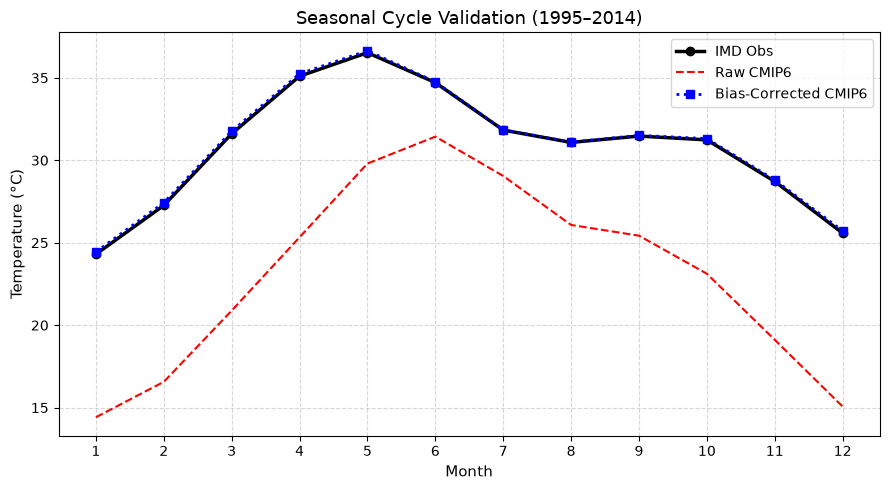

In [13]:
import matplotlib.pyplot as plt

# Mask the model fields to IMD's land-only footprint (obs_clipped is NaN
# over ocean) so all three domain-mean curves are computed over the same
# grid cells.
land_mask = obs_clipped.notnull()

obs_season = obs_clipped.mean(dim=["lat", "lon"]).groupby("time.month").mean("time")
raw_season = (
    hist_regridded.where(land_mask).mean(dim=["lat", "lon"]).groupby("time.month").mean("time")
)
corr_season = (
    hist_adjusted.where(land_mask).mean(dim=["lat", "lon"]).groupby("time.month").mean("time")
)

plt.figure(figsize=(9, 5))
# IMD Obs as a solid thick black line with point markers
plt.plot(
    obs_season.month,
    obs_season,
    label="IMD Obs",
    color="black",
    linewidth=2.5,
    marker="o",
)
# Raw CMIP6 model
plt.plot(
    raw_season.month,
    raw_season,
    label="Raw CMIP6",
    color="red",
    linestyle="--",
    linewidth=1.5,
)
# Bias-Corrected CMIP6 as a dashed blue line with square markers so it doesn't hide IMD
plt.plot(
    corr_season.month,
    corr_season,
    label="Bias-Corrected CMIP6",
    color="blue",
    linestyle=":",
    linewidth=2,
    marker="s",
)

plt.xlabel("Month", fontsize=11)
plt.ylabel("Temperature (°C)", fontsize=11)
plt.title("Seasonal Cycle Validation (1995–2014)", fontsize=13)
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

**4.8 — Distribution match check.**
Overlay histograms of all valid grid-cell/time values for obs, raw model,
and corrected model — the classic quantile-mapping diagnostic: a good
correction should visibly pull the red (raw) distribution onto the black
(obs) one, with blue (corrected) tracking it closely.

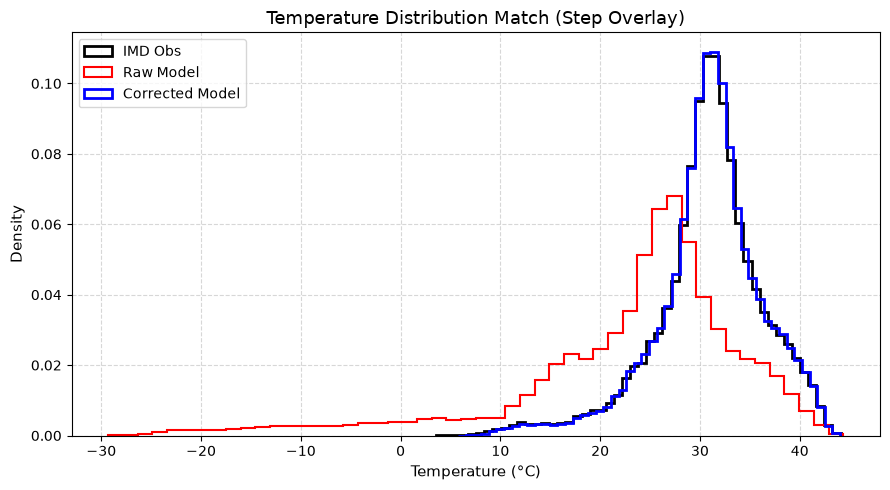

In [14]:
import numpy as np

# Same land-only mask as 4.7, applied before flattening, so all three
# histograms are drawn from identical grid cells.
land_mask = obs_clipped.notnull()

obs_vals = obs_clipped.values.flatten()
raw_vals = hist_regridded.where(land_mask).values.flatten()
corr_vals = hist_adjusted.where(land_mask).values.flatten()

# Remove NaNs
obs_vals = obs_vals[~np.isnan(obs_vals)]
raw_vals = raw_vals[~np.isnan(raw_vals)]
corr_vals = corr_vals[~np.isnan(corr_vals)]


plt.figure(figsize=(9, 5))

# Plot as step histograms (outlines) instead of filled bars
plt.hist(
    obs_vals,
    bins=50,
    histtype="step",
    linewidth=2,
    label="IMD Obs",
    color="black",
    density=True,
)
plt.hist(
    raw_vals,
    bins=50,
    histtype="step",
    linewidth=1.5,
    label="Raw Model",
    color="red",
    density=True,
)
plt.hist(
    corr_vals,
    bins=50,
    histtype="step",
    linewidth=2,
    label="Corrected Model",
    color="blue",
    density=True,
)

plt.xlabel("Temperature (°C)", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.title("Temperature Distribution Match (Step Overlay)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 5. Apply the bias correction to the future SSP2-4.5 projection

Same preprocessing as Section 4 (unit conversion, regridding), now applied
to the future projection — then we hand it to the trained EQM model to
apply the learned correction. Uses `region_ssp` (the India-cropped SSP
dataset from Section 2), consistent with the historical side above.

In [15]:
ssp_da = region_ssp["tas"]

if ssp_da.attrs.get("units") == "K" or ssp_da.mean() > 200:
    ssp_da = ssp_da - 273.15
    ssp_da.attrs["units"] = "degC"

ssp_clipped = ssp_da.sel(time=slice("2015-01-01", "2100-12-31"))
ssp_regridded = ssp_clipped.interp(lat=obs_clipped.lat, lon=obs_clipped.lon, method="linear")

# Apply the trained empirical quantile mapping adjustment to the future projection
ssp_adjusted = qm_trained.adjust(ssp_regridded)

print(ssp_adjusted)

<xarray.DataArray 'scen' (lat: 31, time: 1032, lon: 31)> Size: 8MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, na

## 6. Compute warming anomalies relative to the observed baseline

We express future temperatures as anomalies (°C above/below normal) rather
than absolute values, using the *observed* 1995–2014 monthly climatology as
the baseline — this is what the bias correction in Sections 4–5 buys us: a
baseline that's grounded in IMD observations rather than the raw model's
own (biased) historical mean.

In [16]:
historical_baseline = obs_clipped.groupby("time.month").mean("time")
ssp_anomalies = ssp_adjusted.groupby("time.month") - historical_baseline

print(ssp_anomalies)

<xarray.DataArray (lat: 31, time: 1032, lon: 31)> Size: 8MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan,

## 7. Aggregate into near-term and long-term windows

Average the monthly anomalies over two 30-year windows to get stable
spatial warming signals: near-term (2021–2050) and long-term (2071–2100,
end-of-century under SSP2-4.5).

In [17]:
near_term = ssp_anomalies.sel(time=slice("2021-01-01", "2050-12-31"))
long_term = ssp_anomalies.sel(time=slice("2071-01-01", "2100-12-31"))

near_term_mean = near_term.mean(dim="time")
long_term_mean = long_term.mean(dim="time")

print("Near-term mean calculated:", near_term_mean.shape)
print("Long-term mean calculated:", long_term_mean.shape)

Near-term mean calculated: (31, 31)
Long-term mean calculated: (31, 31)


## 8. Visualize spatial warming patterns

Plot both warming windows side by side with Indian district boundaries
overlaid for geographic context.

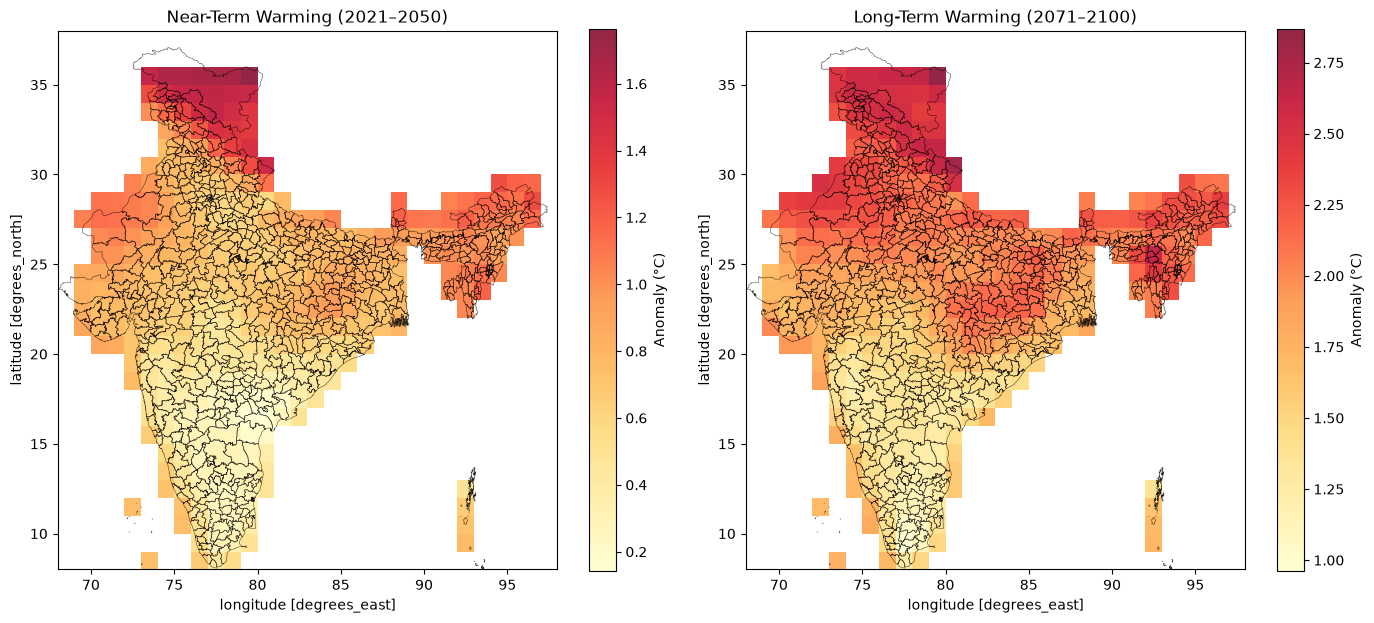

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load India districts GeoJSON
districts_url = "https://raw.githubusercontent.com/HariKumarValluru/India-Map-with-States-and-Districts-GeoJson/master/districts.geojson"
districts = gpd.read_file(districts_url)

# Optional: zoom into a specific state, e.g. Telangana
# state_districts = districts[districts['STATE'] == 'Telangana']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Near-term spatial plot with district boundaries
near_term_mean.plot(ax=axes[0], x = "lon", y = "lat", cmap="YlOrRd", cbar_kwargs={"label": "Anomaly (°C)"}, alpha=0.85)
districts.boundary.plot(ax=axes[0], color="black", linewidth=0.4, alpha=0.7)
axes[0].set_title("Near-Term Warming (2021–2050)")
axes[0].set_xlim(68, 98)
axes[0].set_ylim(8, 38)

# Long-term spatial plot with district boundaries
long_term_mean.plot(ax=axes[1],  x = "lon", y = "lat", cmap="YlOrRd", cbar_kwargs={"label": "Anomaly (°C)"}, alpha=0.85)
districts.boundary.plot(ax=axes[1], color="black", linewidth=0.4, alpha=0.7)
axes[1].set_title("Long-Term Warming (2071–2100)")
axes[1].set_xlim(68, 98)
axes[1].set_ylim(8, 38)

plt.tight_layout()
plt.savefig("../outputs/india_warming_districts.png", dpi=300, bbox_inches="tight")
plt.show()

## Notes & caveats

- **NaN cells are expected.** IMD's gridded product only covers Indian
  landmass, so ocean and coastal-edge grid cells will be `NaN` throughout
  the observational and bias-corrected arrays — this is not a computation
  error, it's the extent of the source data.
- **Single model, single realization.** This uses MRI-ESM2-0 (r1i1p1f1)
  only, not a multi-model ensemble — treat the magnitude of warming as
  illustrative of one model's bias-corrected response, not a consensus
  estimate. Compare against the ACCESS-CM2-based multi-scenario notebook
  for a sense of inter-model spread.
- **Bias correction assumes stationarity.** EQM assumes the model's bias
  structure learned on 1995–2014 remains valid through 2100; this is a
  standard simplifying assumption in bias correction, not a guarantee.
- **Validation metrics (4.6–4.8) are in-sample.** They're computed by
  reapplying the trained correction to its own training period
  (1995–2014), so they confirm the EQM fit converged, not that it
  generalizes to the future projection. Treat them as a fit sanity-check,
  not as skill scores for the SSP2-4.5 output in Sections 5–8.
- **Model-vs-obs comparisons are restricted to IMD's land footprint.**
  The raw and corrected model fields have valid values over ocean, IMD
  does not — validation cells mask the model to IMD's land-only cells so
  the comparisons are like-for-like; keep that masking if you extend the
  validation section further.
